# EDA for MovieLens Recommendation Project

## Problemformulering

Målet är att bygga ett filmrekommendationssystem med användarbetyg som huvudsaklig signal. Den primära ansatsen är collaborative filtering, vilket innebär att rekommendationer baseras på mönster i hur användare med liknande beteende har betygsatt filmer.

EDA:n nedan används för att förstå datakvalitet, sparsity, användar- och filmbeteende samt vilka begränsningar och beslut som är rimliga innan modellering.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

In [3]:
movies = pd.read_csv('../ml-latest/movies.csv')
ratings_full = pd.read_csv('../ml-latest/ratings.csv')
tags_full = pd.read_csv('../ml-latest/tags.csv')
links_full = pd.read_csv('../ml-latest/links.csv')

print('movies:', movies.shape)
print('ratings:', ratings_full.shape)
print('tags:', tags_full.shape)
print('links:', links_full.shape)

movies: (86537, 3)
ratings: (33832162, 4)
tags: (2328315, 4)
links: (86537, 3)


## 1. Movies dataset

Först undersöks struktur, dubbletter och genreinformation i `movies`. Det är centralt eftersom metadata senare kan användas som stöd i analys och eventuellt i hybrid- eller content-baserade delar av systemet.

In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86537 entries, 0 to 86536
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  86537 non-null  int64 
 1   title    86537 non-null  object
 2   genres   86537 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.0+ MB


In [6]:
movie_duplicates_summary = pd.Series({
    'duplicate_movieId': movies['movieId'].duplicated().sum(),
    'duplicate_titles': movies['title'].duplicated().sum(),
    'missing_titles': movies['title'].isna().sum(),
    'missing_genres': movies['genres'].isna().sum(),
})

movie_duplicates_summary

duplicate_movieId      0
duplicate_titles     207
missing_titles         0
missing_genres         0
dtype: int64

`movieId` verkar vara en stabil nyckel utan dubbletter, medan vissa filmtitlar återkommer flera gånger. Det är inte nödvändigtvis ett problem eftersom olika filmer kan dela titel, till exempel på grund av remakes, alternativa utgåvor eller olika årtal.

In [7]:
duplicate_titles = (
    movies['title']
    .value_counts()
    .loc[lambda s: s > 1]
    .rename_axis('title')
    .reset_index(name='count')
)

duplicate_titles.head(10)

,title,count
0,Alone (2020),4
1,The Plague (2006),3
2,Journey to the Center of the Earth (2008),3
3,The Box (2021),3
4,Deranged (2012),2
5,The Dream Team (2012),2
6,Good People (2014),2
7,Weekend (2011),2
8,War of the Worlds (2005),2
9,Savage (2011),2


In [8]:
genre_counts = movies['genres'].value_counts()
genre_counts.head(10)

genres
Drama                   12246
Documentary              8064
Comedy                   7689
(no genres listed)       7060
Comedy|Drama             3196
Drama|Romance            2788
Horror                   2467
Comedy|Romance           2176
Thriller                 1397
Comedy|Drama|Romance     1310
Name: count, dtype: int64

In [9]:
split_genre_counts = (
    movies.assign(genres_split=movies['genres'].str.split('|'))
    .explode('genres_split')
    ['genres_split']
    .value_counts()
)

split_genre_counts

genres_split
Drama                 33681
Comedy                22830
Thriller              11675
Romance               10172
Action                 9563
Documentary            9283
Horror                 8570
(no genres listed)     7060
Crime                  6917
Adventure              5349
Sci-Fi                 4850
Animation              4579
Children               4367
Mystery                3972
Fantasy                3821
War                    2301
Western                1690
Musical                1059
Film-Noir               354
IMAX                    195
Name: count, dtype: int64

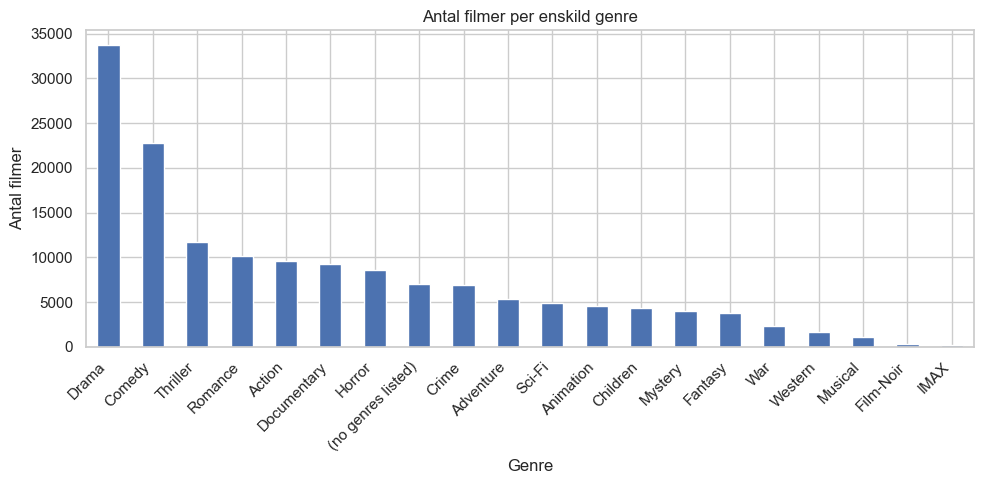

In [10]:
plt.figure(figsize=(10, 5))
split_genre_counts.plot(kind='bar')
plt.title('Antal filmer per enskild genre')
plt.xlabel('Genre')
plt.ylabel('Antal filmer')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
no_genre_mask = movies['genres'] == '(no genres listed)'
no_genre_movies = movies[no_genre_mask]
no_genre_share = no_genre_mask.mean()

print(f"Antal filmer utan genreinfo: {no_genre_movies.shape[0]}")
print(f"Andel filmer utan genreinfo: {no_genre_share:.2%}")
no_genre_movies.head()

Antal filmer utan genreinfo: 7060
Andel filmer utan genreinfo: 8.16%


,movieId,title,genres
15884,83773,Away with Words (San tiao ren) (1999),(no genres listed)
16063,84768,Glitterbug (1994),(no genres listed)
16354,86493,"Age of the Earth, The (A Idade da Terra) (1980)",(no genres listed)
16494,87061,Trails (Veredas) (1978),(no genres listed)
17410,91246,Milky Way (Tejút) (2007),(no genres listed)


`'(no genres listed)'` behandlas här som saknad eller otillräcklig metadata snarare än som en verklig genre. Det är viktigt eftersom en stor mängd filmer utan genreinfo försämrar möjligheten att använda metadata som stöd i analysen.

## 2. Ratings dataset

Eftersom rekommendationssystemet i första hand bygger på användarbetyg behöver `ratings` undersökas noggrant. Fokus ligger på fördelning av ratingvärden, aktivitet per användare, aktivitet per film och hur tidsdimensionen ser ut.

In [12]:
ratings_full.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


In [13]:
ratings_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33832162 entries, 0 to 33832161
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 1.0 GB


In [14]:
ratings_quality = pd.Series({
    'missing_userId': ratings_full['userId'].isna().sum(),
    'missing_movieId': ratings_full['movieId'].isna().sum(),
    'missing_rating': ratings_full['rating'].isna().sum(),
    'duplicate_rows': ratings_full.duplicated().sum(),
    'n_unique_users': ratings_full['userId'].nunique(),
    'n_unique_movies': ratings_full['movieId'].nunique(),
})

ratings_quality

missing_userId          0
missing_movieId         0
missing_rating          0
duplicate_rows          0
n_unique_users     330975
n_unique_movies     83239
dtype: int64

In [15]:
rating_distribution = ratings_full['rating'].value_counts().sort_index()
rating_distribution

rating
0.5     566306
1.0    1013645
1.5     562409
2.0    2146492
2.5    1760733
3.0    6400664
3.5    4465001
4.0    8835955
4.5    3123055
5.0    4957902
Name: count, dtype: int64

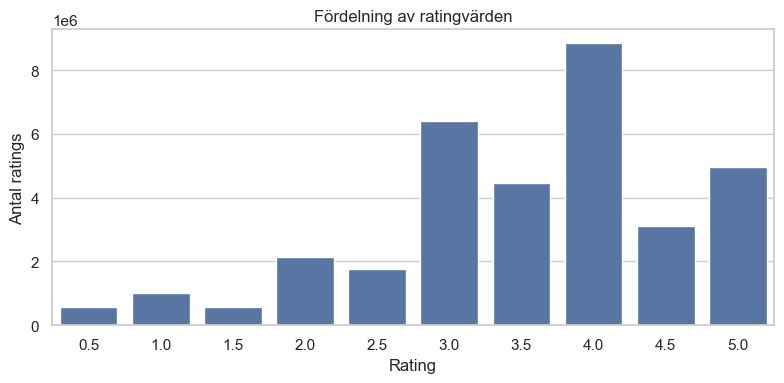

In [16]:
plt.figure(figsize=(8, 4))
sns.countplot(data=ratings_full, x='rating', order=sorted(ratings_full['rating'].unique()))
plt.title('Fördelning av ratingvärden')
plt.xlabel('Rating')
plt.ylabel('Antal ratings')
plt.tight_layout()
plt.show()

In [17]:
ratings_per_user = ratings_full.groupby('userId').size()
ratings_per_movie = ratings_full.groupby('movieId').size()

display(ratings_per_user.describe())
display(ratings_per_movie.describe())

count    330975.00000
mean        102.21969
std         232.15453
min           1.00000
25%          15.00000
50%          31.00000
75%          98.00000
max       33332.00000
dtype: float64

count     83239.000000
mean        406.446041
std        2806.975876
min           1.000000
25%           2.000000
50%           5.000000
75%          26.000000
max      122296.000000
dtype: float64

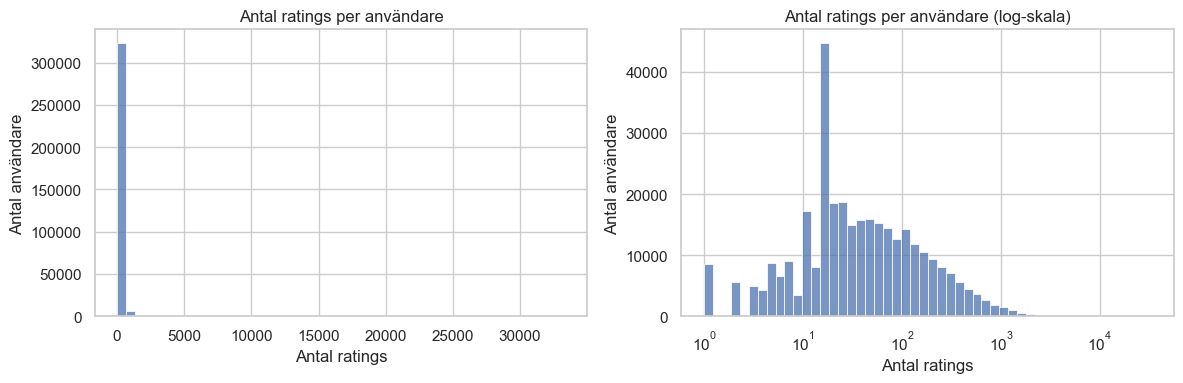

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(ratings_per_user, bins=50, ax=ax[0])
sns.histplot(ratings_per_user, bins=50, log_scale=True, ax=ax[1])
ax[0].set_title('Antal ratings per användare')
ax[1].set_title('Antal ratings per användare (log-skala)')
ax[0].set_xlabel('Antal ratings')
ax[1].set_xlabel('Antal ratings')
ax[0].set_ylabel('Antal användare')
ax[1].set_ylabel('Antal användare')
plt.tight_layout()
plt.show()

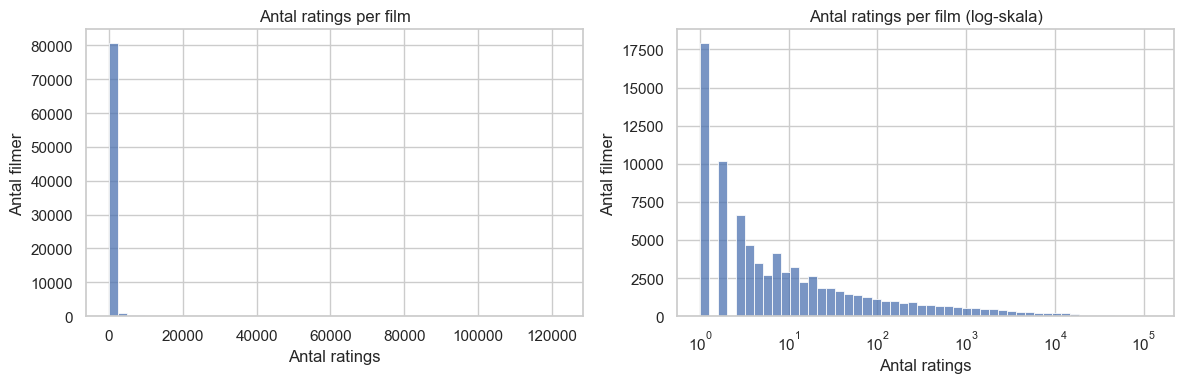

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(ratings_per_movie, bins=50, ax=ax[0])
sns.histplot(ratings_per_movie, bins=50, log_scale=True, ax=ax[1])
ax[0].set_title('Antal ratings per film')
ax[1].set_title('Antal ratings per film (log-skala)')
ax[0].set_xlabel('Antal ratings')
ax[1].set_xlabel('Antal ratings')
ax[0].set_ylabel('Antal filmer')
ax[1].set_ylabel('Antal filmer')
plt.tight_layout()
plt.show()

Både användaraktivitet och filmaktivitet är tydligt skeva. Några användare har satt väldigt många betyg, medan många användare bara har satt ett litet antal. Samma mönster syns för filmer: ett litet antal populära filmer står för en stor del av alla ratings, medan många filmer har få betyg.

In [20]:
ratings_full['timestamp'] = pd.to_datetime(ratings_full['timestamp'], unit='s')
ratings_full['year'] = ratings_full['timestamp'].dt.year

ratings_by_year = ratings_full['year'].value_counts().sort_index()
ratings_by_year.tail(10)

year
2014     566628
2015    1853975
2016    2005979
2017    1899523
2018    1455193
2019    1450218
2020    1763532
2021    1297525
2022     953347
2023     562624
Name: count, dtype: int64

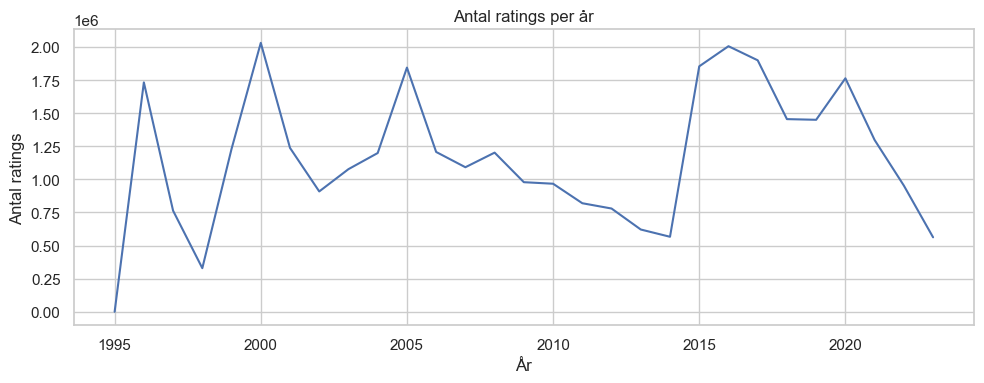

In [21]:
plt.figure(figsize=(10, 4))
ratings_by_year.plot()
plt.title('Antal ratings per år')
plt.xlabel('År')
plt.ylabel('Antal ratings')
plt.tight_layout()
plt.show()

Tidsfördelningen är relevant eftersom användarbeteende, filmsläpp och popularitet kan förändras över tid. Om datan är koncentrerad till vissa år kan det påverka hur representativ modellen blir.

## 3. Tags dataset

Tags är inte huvudsignalen i collaborative filtering, men de kan vara värdefulla för att förstå filmer som saknar tydlig genreinformation eller framförallt senare användas i en hybridmodell.

In [22]:
tags_full.head()

,userId,movieId,tag,timestamp
0,10,260,good vs evil,1430666558
1,10,260,Harrison Ford,1430666505
2,10,260,sci-fi,1430666538
3,14,1221,Al Pacino,1311600756
4,14,1221,mafia,1311600746


In [23]:
tags_quality = pd.Series({
    'missing_userId': tags_full['userId'].isna().sum(),
    'missing_movieId': tags_full['movieId'].isna().sum(),
    'missing_tag': tags_full['tag'].isna().sum(),
    'n_unique_movies_with_tags': tags_full['movieId'].nunique(),
    'n_unique_tags': tags_full['tag'].nunique(),
})

tags_quality

missing_userId                    0
missing_movieId                   0
missing_tag                      17
n_unique_movies_with_tags     53452
n_unique_tags                153949
dtype: int64

In [24]:
tag_counts = tags_full['tag'].value_counts()
tag_counts.head(20)

tag
sci-fi                14319
atmospheric           12172
action                10683
comedy                10161
surreal                9142
funny                  9094
visually appealing     8890
twist ending           8325
thought-provoking      7727
dark comedy            7659
based on a book        7584
dystopia               6975
cinematography         6473
social commentary      6369
romance                6338
violence               6300
stylized               6163
psychology             6111
fantasy                6082
murder                 5955
Name: count, dtype: int64

In [25]:
no_genre_movie_ids = no_genre_movies['movieId']
no_genre_tags = tags_full[tags_full['movieId'].isin(no_genre_movie_ids)]

print(f"Filmer utan genreinfo: {no_genre_movie_ids.nunique()}")
print(f"Filmer utan genreinfo som har minst en tag: {no_genre_tags['movieId'].nunique()}")
print(f"Andel filmer utan genreinfo med minst en tag: {no_genre_tags['movieId'].nunique() / no_genre_movie_ids.nunique():.2%}")

Filmer utan genreinfo: 7060
Filmer utan genreinfo som har minst en tag: 2790
Andel filmer utan genreinfo med minst en tag: 39.52%


In [26]:
no_genre_tags['tag'].value_counts().head(20)

tag
woman director      282
cinematography      116
short               106
horror               99
musical              94
documentary          92
murder               87
original horror      79
supernatural         77
great acting         76
mental illness       76
short film           75
coming of age        72
independent film     68
cults                68
music                67
BD-R                 66
demonology           62
thriller             59
Criterion            56
Name: count, dtype: int64

Om en meningsfull andel av filmerna utan genreinfo har tags finns det stöd för att tags senare kan användas som komplement. Om täckningen däremot är låg bör `'(no genres listed)'` i första hand behandlas som saknad metadata snarare än att försöka imputera genre.

### Links dataset

In [27]:
links_full.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


## 4. Merge och övergripande interaktionsdata

Nästa steg är att slå ihop `ratings` och `movies` för att analysera den faktiska user-item-datan som collaborative filtering kommer att använda.

In [28]:
rated_movies = ratings_full.merge(movies, on='movieId', how='inner')
rated_movies.head()

,userId,movieId,rating,timestamp,year,title,genres
0,1,1,4.0,2008-11-03 17:52:19,2008,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,110,4.0,2008-11-05 06:04:46,2008,Braveheart (1995),Action|Drama|War
2,1,158,4.0,2008-11-03 17:31:43,2008,Casper (1995),Adventure|Children
3,1,260,4.5,2008-11-03 18:00:04,2008,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
4,1,356,5.0,2008-11-03 17:58:39,2008,Forrest Gump (1994),Comedy|Drama|Romance|War


In [29]:
interaction_summary = pd.Series({
    'n_users': rated_movies['userId'].nunique(),
    'n_movies': rated_movies['movieId'].nunique(),
    'n_ratings': len(rated_movies),
    'avg_ratings_per_user': rated_movies.groupby('userId').size().mean(),
    'avg_ratings_per_movie': rated_movies.groupby('movieId').size().mean(),
})

interaction_summary

n_users                  3.309750e+05
n_movies                 8.323900e+04
n_ratings                3.383216e+07
avg_ratings_per_user     1.022197e+02
avg_ratings_per_movie    4.064460e+02
dtype: float64

In [30]:
def density(df):
    n_users = df['userId'].nunique()
    n_movies = df['movieId'].nunique()
    n_ratings = len(df)
    return n_ratings / (n_users * n_movies)

full_density = density(rated_movies)
full_sparsity = 1 - full_density

print(f'Density: {full_density:.6f} ({full_density * 100:.4f}%)')
print(f'Sparsity: {full_sparsity:.6f} ({full_sparsity * 100:.4f}%)')

Density: 0.001228 (0.1228%)
Sparsity: 0.998772 (99.8772%)


Interaktionsmatrisen är mycket gles, vilket är normalt i rekommendationsproblem men ändå viktigt att konstatera. Hög sparsity gör att neighbourhood-baserade metoder kan få svårt att hitta tillräckligt många överlapp mellan användare och filmer.

In [31]:
ratings_per_movie_sorted = ratings_full.groupby('movieId').size().sort_values(ascending=False)
cumulative_share = ratings_per_movie_sorted.cumsum() / ratings_per_movie_sorted.sum()
top_10_share = ratings_per_movie_sorted.head(int(len(ratings_per_movie_sorted) * 0.10)).sum() / ratings_per_movie_sorted.sum()

print(f'De 10 % mest populära filmerna står för {top_10_share:.2%} av alla ratings.')

De 10 % mest populära filmerna står för 95.79% av alla ratings.


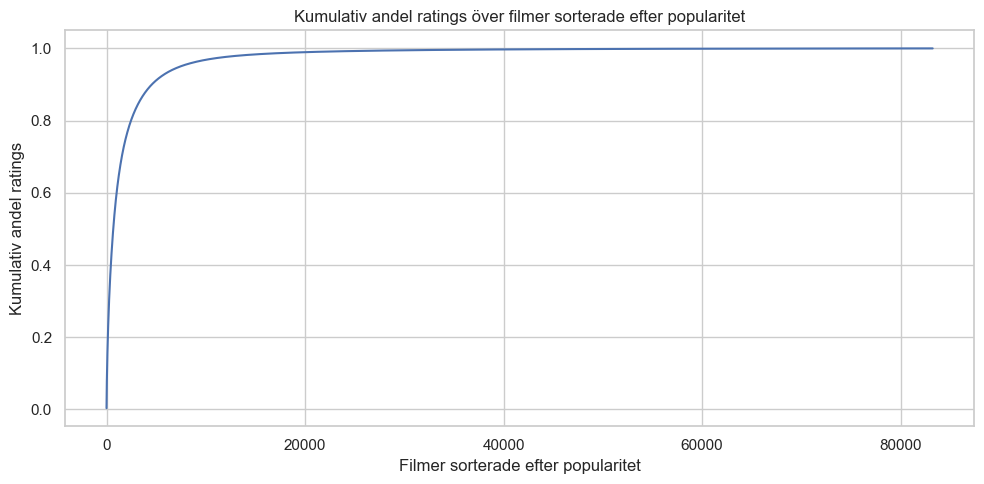

In [32]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumulative_share) + 1), cumulative_share.values)
plt.title('Kumulativ andel ratings över filmer sorterade efter popularitet')
plt.xlabel('Filmer sorterade efter popularitet')
plt.ylabel('Kumulativ andel ratings')
plt.tight_layout()
plt.show()

Long tail-mönstret innebär att många filmer har mycket begränsad interaktionshistorik. Det kan ge bias mot populära filmer i rekommendationerna och göra cold-start och coverage till viktiga frågor senare i projektet.

## 5. Effekt av att filtrera inaktiva användare

Eftersom många användare har få ratings kan det vara rimligt att testa ett minimumkrav, men det beslutet bör baseras på vad filtret faktiskt gör med datan.

In [33]:
min_ratings_threshold = 50
active_users = ratings_per_user[ratings_per_user >= min_ratings_threshold].index
rated_movies_active = rated_movies[rated_movies['userId'].isin(active_users)].copy()

In [34]:
before_after = pd.DataFrame({
    'before': [
        rated_movies['userId'].nunique(),
        rated_movies['movieId'].nunique(),
        len(rated_movies),
        density(rated_movies),
    ],
    'after': [
        rated_movies_active['userId'].nunique(),
        rated_movies_active['movieId'].nunique(),
        len(rated_movies_active),
        density(rated_movies_active),
    ]
}, index=['n_users', 'n_movies', 'n_ratings', 'density'])

before_after

,before,after
n_users,3.309750e+05,1.305610e+05
n_movies,8.323900e+04,8.268700e+04
n_ratings,3.383216e+07,3.015336e+07
density,1.228026e-03,2.793091e-03


In [35]:
loss_summary = pd.Series({
    'user_loss_pct': 1 - (rated_movies_active['userId'].nunique() / rated_movies['userId'].nunique()),
    'movie_loss_pct': 1 - (rated_movies_active['movieId'].nunique() / rated_movies['movieId'].nunique()),
    'rating_loss_pct': 1 - (len(rated_movies_active) / len(rated_movies)),
})

loss_summary.apply(lambda x: f'{x:.2%}')

user_loss_pct      60.55%
movie_loss_pct      0.66%
rating_loss_pct    10.87%
dtype: object

Detta steg gör det möjligt att avgöra om filtret `>= 50 ratings` är rimligt. Om density förbättras tydligt utan att alltför mycket information går förlorad kan filtret vara motiverat. Om däremot stora delar av både ratings och filmer försvinner behöver tröskeln omprövas.

### Ytterligare utforskning av användare - frekvens av ratings och uppdelning i grupper

In [36]:
user_quantiles = ratings_per_user.quantile([0.50, 0.90, 0.99])
user_quantiles

0.50      31.0
0.90     250.0
0.99    1046.0
dtype: float64

In [37]:
q50_user = ratings_per_user.quantile(0.50)
q90_user = ratings_per_user.quantile(0.90)
q99_user = ratings_per_user.quantile(0.99)

low_act_indices = ratings_per_user[ratings_per_user < q50_user].index
med_act_indices = ratings_per_user[(ratings_per_user >= q50_user) & (ratings_per_user < q90_user)].index
high_act_indices = ratings_per_user[(ratings_per_user >= q90_user) & (ratings_per_user < q99_user)].index
expert_act_indices = ratings_per_user[ratings_per_user >= q99_user].index

def mean_rating_for_users(user_idx):
    return ratings_full.loc[ratings_full["userId"].isin(user_idx), "rating"].mean()

user_activity_summary = pd.DataFrame({
    "n_users": [
        len(low_act_indices),
        len(med_act_indices),
        len(high_act_indices),
        len(expert_act_indices)
    ],
    "avg_ratings_per_user": [
        ratings_per_user[ratings_per_user.index.isin(low_act_indices)].mean(),
        ratings_per_user[ratings_per_user.index.isin(med_act_indices)].mean(),
        ratings_per_user[ratings_per_user.index.isin(high_act_indices)].mean(),
        ratings_per_user[ratings_per_user.index.isin(expert_act_indices)].mean(),
    ],
    "mean_rating_for_users": [
        mean_rating_for_users(low_act_indices),
        mean_rating_for_users(med_act_indices),
        mean_rating_for_users(high_act_indices),
        mean_rating_for_users(expert_act_indices)
    ]
}, index=["low_activity_users", "medium_activity_users", "high_activity_users", "expert_activity_users"])

user_activity_summary


,n_users,avg_ratings_per_user,mean_rating_for_users
low_activity_users,164084,13.754260,3.651895
medium_activity_users,133771,93.142774,3.727342
high_activity_users,29806,455.523720,3.485215
expert_activity_users,3314,1671.142426,3.222749


Note: Experter (enligt gränser jag själv satt) är generellt mer sparsamma i sina ratings jämfört med Medium och high. Även om jag minskar gränsen från 2500 till 1500 så är det fortfarande en liknande skillnad. Frågan är hur mycket man vill lite på "experterna" i denna fråga, det är ju fullt möjligt att en användare känner mer som en medium-activity användare.

Istället för egensatta gränser har jag valt att använda mig av kvartiler, vilket verkar vara en väldigt mycket mer rimlig fördelning och fungerar bra på data som är så tydligt högerskev med lång svans.

In [38]:
movie_quantiles = ratings_per_movie.quantile([0.50, 0.75, 0.90, 0.99])
movie_quantiles

0.50        5.00
0.75       26.00
0.90      263.00
0.99    10068.96
dtype: float64

In [39]:
q50 = ratings_per_movie.quantile(0.50)
q90 = ratings_per_movie.quantile(0.90)
q99 = ratings_per_movie.quantile(0.99)

low_rat_movies_idx = ratings_per_movie[ratings_per_movie < q50].index
med_rat_movies_idx = ratings_per_movie[(ratings_per_movie >= q50) & (ratings_per_movie < q90)].index
high_rat_movies_idx = ratings_per_movie[(ratings_per_movie >= q90) & (ratings_per_movie < q99)].index
very_high_rat_movies_idx = ratings_per_movie[ratings_per_movie >= q99].index

def mean_rating_for_movie(movie_idx):
    return ratings_full.loc[ratings_full["movieId"].isin(movie_idx), "rating"].mean()

low_rated_movies_mean = mean_rating_for_movie(low_rat_movies_idx)
med_rated_movies_mean = mean_rating_for_movie(med_rat_movies_idx)
high_rated_movies_mean = mean_rating_for_movie(high_rat_movies_idx)
very_high_rated_movies_mean = mean_rating_for_movie(very_high_rat_movies_idx)

movie_ratings_summary = pd.DataFrame({
    "n_movies": [
        len(low_rat_movies_idx),
        len(med_rat_movies_idx),
        len(high_rat_movies_idx),
        len(very_high_rat_movies_idx)
    ],
    "avg_ratings_per_movie": [
        ratings_per_movie[ratings_per_movie.index.isin(low_rat_movies_idx)].mean(),
        ratings_per_movie[ratings_per_movie.index.isin(med_rat_movies_idx)].mean(),
        ratings_per_movie[ratings_per_movie.index.isin(high_rat_movies_idx)].mean(),
        ratings_per_movie[ratings_per_movie.index.isin(very_high_rat_movies_idx)].mean(),
    ],
    "mean_rating_for_movies": [
        low_rated_movies_mean,
        med_rated_movies_mean,
        high_rated_movies_mean,
        very_high_rated_movies_mean
    ]}, index=["low_rated_movies", "medium_rated_movies", "high_rated_movies", "very_high_rat_movies"])

display(user_activity_summary)
display(movie_ratings_summary)

,n_users,avg_ratings_per_user,mean_rating_for_users
low_activity_users,164084,13.754260,3.651895
medium_activity_users,133771,93.142774,3.727342
high_activity_users,29806,455.523720,3.485215
expert_activity_users,3314,1671.142426,3.222749


,n_movies,avg_ratings_per_movie,mean_rating_for_movies
low_rated_movies,39366,1.950414,2.919146
medium_rated_movies,35544,37.875253,3.162027
high_rated_movies,7496,1840.354456,3.368275
very_high_rat_movies,833,22345.554622,3.701786


Jag kommer med stor sannolikhet i slutändan använda alla filmer i min TF-IDF eftersom filmer med lågt antal ratings ändå kan ha ok tags, men kommer ta bort filmer med under 30 ratings i min collaborative model.

## Sparsity comparison

In [40]:
active_density = density(rated_movies_active)
print(f'Full density: {full_density * 100:.4f}%')
print(f'Density filtered: {active_density * 100:.4f}%')

Full density: 0.1228%
Density filtered: 0.2793%


Filtreringen till aktiva användare ökade densiteten från 0.1228 % till 0.2793 %, alltså mer än en fördubbling. Matrisen är fortfarande mycket gles, men de kvarvarande användarna har fler interaktioner, vilket ofta ger bättre förutsättningar för rekommendationssystem. Nackdelen är att analysen blir mindre representativ för hela användarbasen.

## 6. EDA-slutsatser

De viktigaste observationerna från denna EDA är:

1. `movies` har en stabil nyckel i `movieId`. Vissa titlar förekommer flera gånger, vilket sannolikt är på grund av olika utgåvor av samma film snarare än felaktiga dubbletter.
2. En del filmer saknar användbar genreinformation genom `'(no genres listed)'`, vilket bör behandlas som saknad metadata i första hand.
3. Ratingdatan är starkt skev både över användare och filmer, vilket innebär att några få användare och populära filmer står för en stor del av interaktionerna.
4. User-item-matrisen är mycket gles, vilket gör rekommendationsproblemet mer utmanande och stärker behovet av robust modellering eller filtrering.
5. Long tail-effekten är tydlig, vilket innebär risk för bias mot populära filmer och svag coverage för mindre populära objekt.
6. Ett användarfilter som `>= 50 ratings` kan vara rimligt, men bör bedömas utifrån faktisk effekt på density och informationsförlust.

Utifrån detta blir nästa steg att jämföra modeller på både ofiltrerad och filtrerad data, samt att tydligt mäta hur olika val påverkar coverage, kvalitet och bias i rekommendationerna.